# Teste de Regressão Linear: Dataset Diabetes

### Dataset : Diabetes (Scikit-Learn)


## Parte A – Tarefas Aplicadas / Código


### 1. Carregando o conjunto de dados


#### Importando Bibliotecas Necessárias & Funções de Utilidade


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="muted")


def format_df_left(df, coluna_texto="Feature", casas_decimais=3):
    """
    Aplica estilo ao DataFrame: formata as casas decimais, alinha
    uma coluna de texto à esquerda e oculta o índice.
    """
    estilo = (
        df.style.format(precision=casas_decimais)
        .set_properties(subset=[coluna_texto], **{"text-align": "left"})
        .set_table_styles(
            {coluna_texto: [{"selector": "th", "props": [("text-align", "left")]}]},
            overwrite=False,
        )
        .hide(axis="index")
    )

    return estilo

#### Carregando dados


In [181]:
data = load_diabetes()
df_diabetes = pd.DataFrame(data.data, columns=data.feature_names)
df_diabetes["target"] = data.target

df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


| Feature    | Descrição                                                                          |
| :--------- | :--------------------------------------------------------------------------------- |
| **age**    | Idade em anos                                                                      |
| **sex**    | Gênero do paciente                                                                 |
| **bmi**    | Índice de Massa Corporal (IMC)                                                     |
| **bp**     | Pressão arterial média                                                             |
| **s1**     | Colesterol sérico total (tc)                                                       |
| **s2**     | Lipoproteínas de baixa densidade (ldl)                                             |
| **s3**     | Lipoproteínas de alta densidade (hdl)                                              |
| **s4**     | Colesterol total / HDL (tch)                                                       |
| **s5**     | Logaritmo do nível de triglicerídeos séricos (ltg)                                 |
| **s6**     | Nível de açúcar no sangue (glu)                                                    |
| **s6**     | Nível de açúcar no sangue (glu)                                                    |
| **target** | Medida quantitativa da progressão da doença um ano após o início do acompanhamento |


In [182]:
df_diabetes.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


### 2. Exploração de Dados (EDA)

#### Correlação das features com o alvo


In [183]:
corr = df_diabetes.corr()
corr_target = corr["target"].drop("target").sort_values(key=abs, ascending=False)
df_corr = corr_target.to_frame("Correlação").rename_axis("Feature").reset_index()

display(format_df_left(df_corr, "Feature"))

Feature,Correlação
bmi,0.586
s5,0.566
bp,0.441
s4,0.430
s3,-0.395
s6,0.382
s1,0.212
age,0.188
s2,0.174
sex,0.043


#### Matriz de Correlação


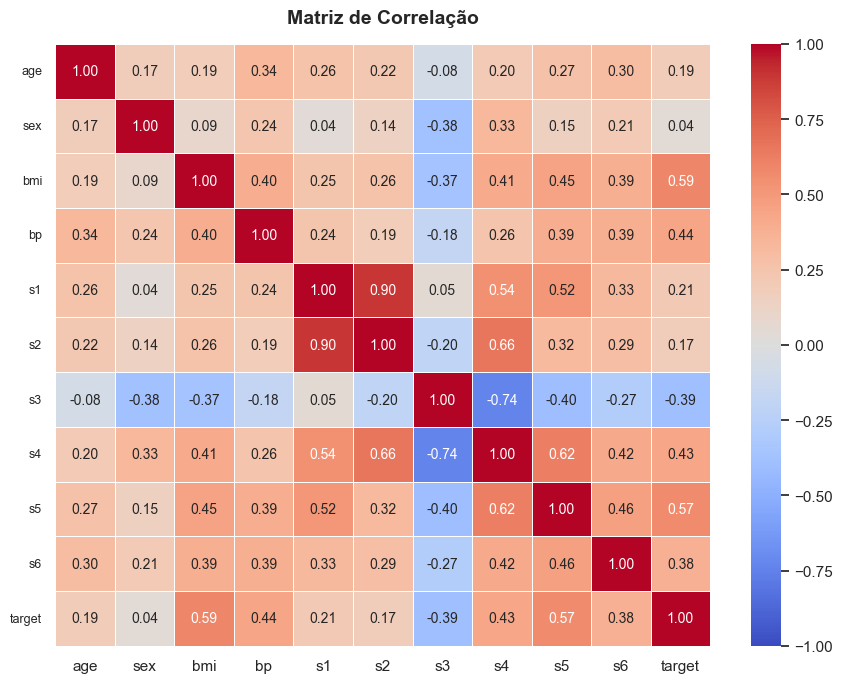

In [184]:
plt.figure(figsize=(9, 7))

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 10},
    linewidths=0.5,
)

plt.title("Matriz de Correlação", fontsize=14, fontweight="bold", pad=15)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

#### Distribuição de valores por features - Histogramas


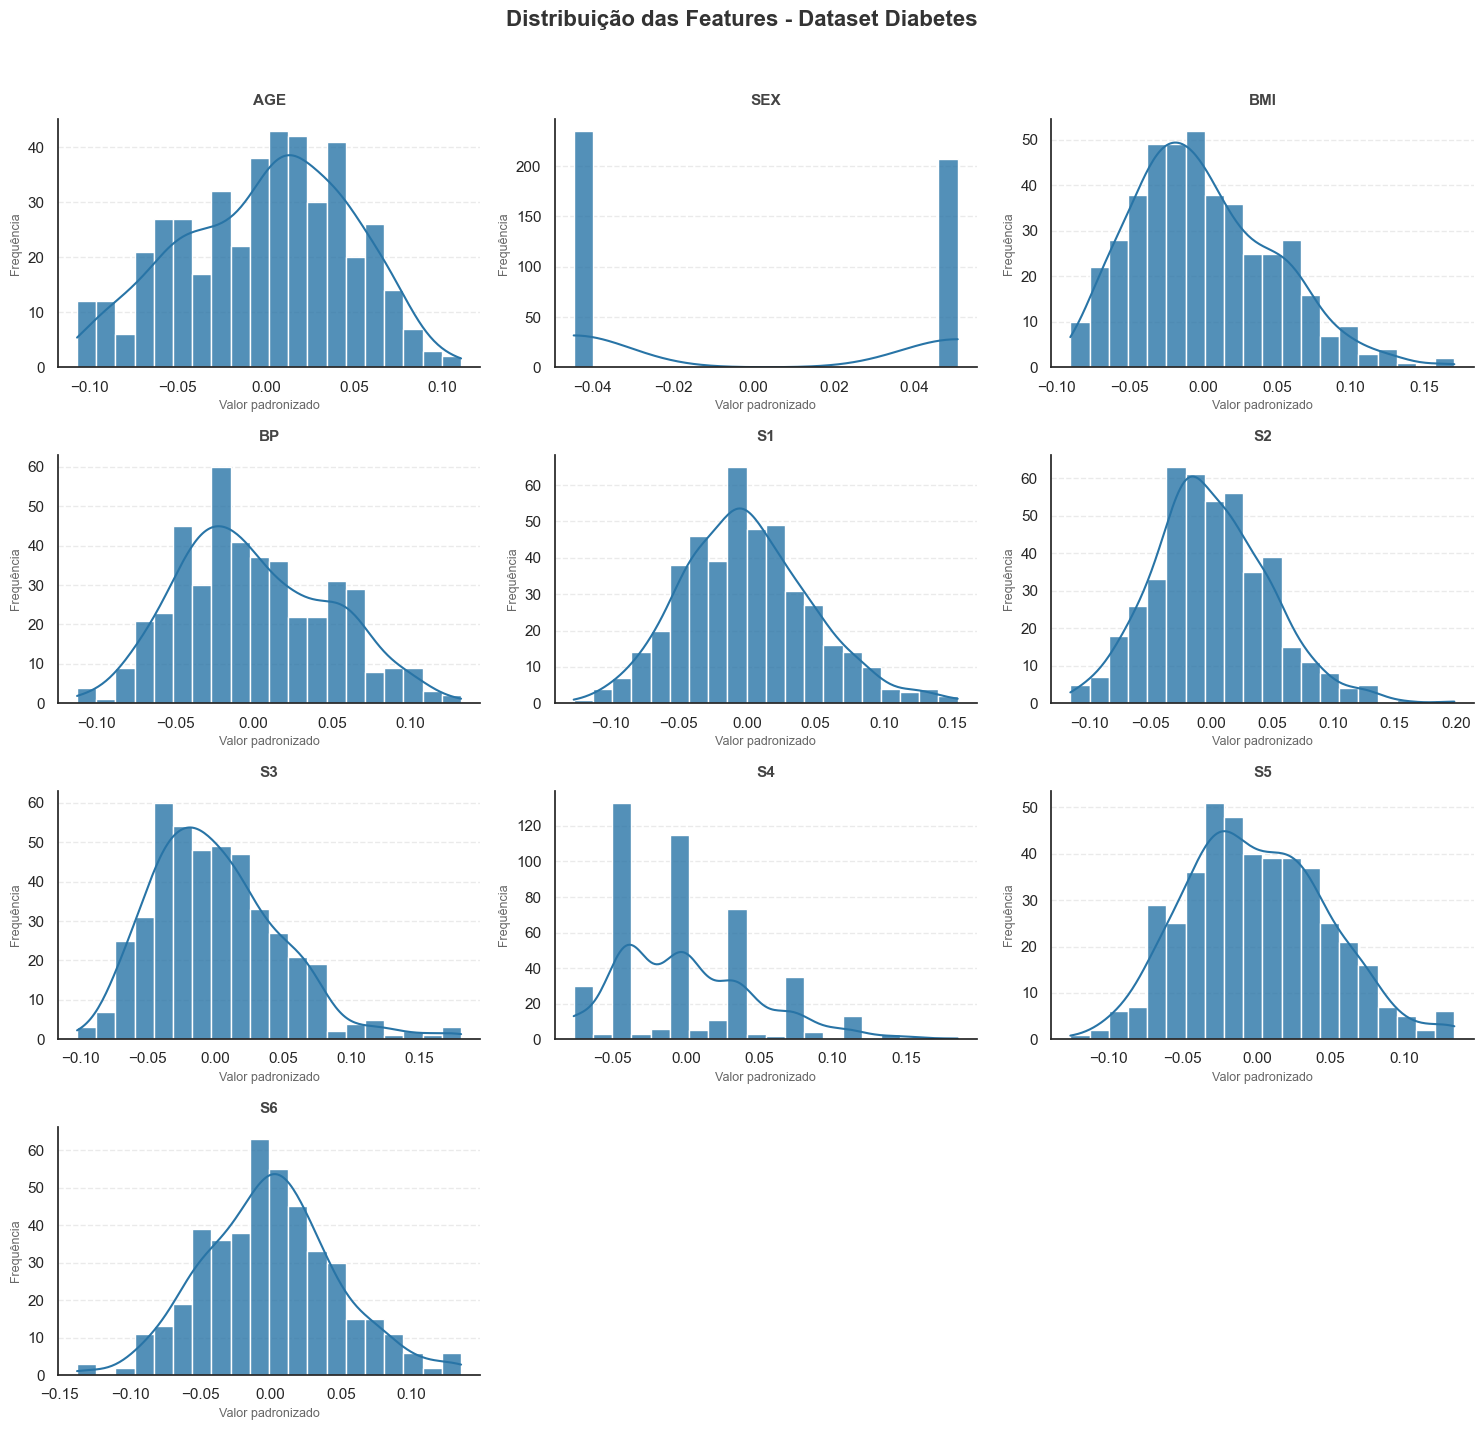

In [185]:
sns.set_theme(style="white", palette="muted")

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle(
    "Distribuição das Features - Dataset Diabetes",
    fontsize=16,
    fontweight="bold",
    color="#333333",
    y=1.02,
)

axes = axes.flatten()

for i, col in enumerate(data.feature_names):
    ax = axes[i]

    sns.histplot(
        df_diabetes[col], bins=20, kde=True, ax=ax, color="#2874A6", edgecolor="white", alpha=0.8
    )

    ax.set_title(col.upper(), fontsize=11, fontweight="bold", color="#444444", pad=10)
    ax.set_xlabel("Valor padronizado", fontsize=9, color="#666666")
    ax.set_ylabel("Frequência", fontsize=9, color="#666666")

    sns.despine(ax=ax)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.delaxes(axes[10])
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

#### Pergunta: Os atributos estão em escalas comparáveis? Seria necessário normalizar/re-escalar as features? Por quê?

As features do dataset Diabetes já foram padronizadas pelo scikit-learn (média ≈ 0, desvio padrão ≈ 1), portanto estão em escalas comparáveis. Em dados brutos, variáveis como pressão arterial (mmHg) e IMC (kg/m²) teriam ordens de grandeza distintas. Nesse caso, a normalização seria necessária para evitar que features com maior variância dominem os coeficientes e tornar os coeficientes comparáveis entre si, além de ser necessário para métodos como ODR, que minimizam distâncias ortogonais e são sensíveis à escala das variáveis.

### 3. Modelo inicial (todas as features)


In [186]:
X_all = df_diabetes[data.feature_names].values
y = df_diabetes["target"].values

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

lr_all = LinearRegression()
lr_all.fit(X_train_all, y_train_all)

r2_train_all = r2_score(y_train_all, lr_all.predict(X_train_all))
r2_test_all = r2_score(y_test_all, lr_all.predict(X_test_all))

coef_df_all = pd.DataFrame({"Feature": data.feature_names, "Coeficiente": lr_all.coef_})
coef_df_all = coef_df_all.sort_values(
    by="Coeficiente", ascending=False, key=abs
).reset_index(drop=True)
display(format_df_left(coef_df_all, "Feature"))

metricas_df = pd.DataFrame(
    {
        "Parâmetro": ["Intercepto", "R² Treino", "R² Teste"],
        "Valor": [lr_all.intercept_, r2_train_all, r2_test_all],
    }
)
display(format_df_left(metricas_df, "Parâmetro"))


Feature,Coeficiente
s1,-931.489
s5,736.199
bmi,542.429
s2,518.062
bp,347.704
s4,275.318
sex,-241.964
s3,163.420
s6,48.671
age,37.904


Parâmetro,Valor
Intercepto,151.346
R² Treino,0.528
R² Teste,0.453


### 4. Seleção de features com correlação


#### Eliminando 2 features com menor correlação com o `target`


In [187]:
removed_features = corr_target.abs().nsmallest(2).index.tolist()
reduced_features = [f for f in data.feature_names if f not in removed_features]

text_md = f"""
**Seleção de features por correlação**

- **Removidas (menor |correlação|):** {", ".join(f"`{f}`" for f in removed_features)}

- **Mantidas ({len(reduced_features)} features):** {", ".join(f"`{f}`" for f in reduced_features)}
"""

display(Markdown(text_md))



**Seleção de features por correlação**

- **Removidas (menor |correlação|):** `sex`, `s2`

- **Mantidas (8 features):** `age`, `bmi`, `bp`, `s1`, `s3`, `s4`, `s5`, `s6`


In [188]:
X_red = df_diabetes[reduced_features].values
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red, y, test_size=0.2, random_state=42
)

lr_red = LinearRegression()

lr_red.fit(X_train_red, y_train_red)

r2_train_red = r2_score(y_train_red, lr_red.predict(X_train_red))
r2_test_red = r2_score(y_test_red, lr_red.predict(X_test_red))

coef_df_red = pd.DataFrame({"Feature": reduced_features, "Coeficiente": lr_red.coef_})
coef_df_red = coef_df_red.sort_values(
    by="Coeficiente", ascending=False, key=abs
).reset_index(drop=True)
display(format_df_left(coef_df_red, "Feature", casas_decimais=2))

metricas_df_red = pd.DataFrame(
    {
        "Parâmetro": ["Intercepto", "R² Treino", "R² Teste"],
        "Valor": [lr_red.intercept_, r2_train_red, r2_test_red],
    }
)
display(format_df_left(metricas_df_red, "Parâmetro"))

Feature,Coeficiente
bmi,603.21
s5,522.94
bp,301.31
s1,-279.11
s4,149.99
s3,-46.47
s6,42.36
age,8.77


Parâmetro,Valor
Intercepto,151.348
R² Treino,0.508
R² Teste,0.439


### 5. Comparação e Reflexão


#### Comparando o desempenho do modelo com todas as features versus o modelo reduzido


In [189]:
df_comp = pd.DataFrame(
    {
        "Modelo": ["Todas as features (10)", "Reduzido (8 features)"],
        "R² Treino": [r2_train_all, r2_train_red],
        "R² Teste": [r2_test_all, r2_test_red],
    }
)

display(format_df_left(df_comp, "Modelo"))

Modelo,R² Treino,R² Teste
Todas as features (10),0.528,0.453
Reduzido (8 features),0.508,0.439


**Qual modelo teve melhor performance no conjunto de teste?**

O Modelo com Todas as features (10) teve melhor performance, atingindo o maior R² no conjunto de teste (0.453 contra 0.439 do reduzido).


## Parte B - OLS vs ODR com uma única feature (`bmi`)

O atributo `bmi` (Índice de Massa Corporal) foi escolhido por ter a maior correlação com o `target` (0.586)


#### Funções de Utilidade

In [190]:
def avaliar_modelo_ols(y_true, y_pred, a, b):
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame(
        {
            "Parâmetro": [
                "Coeficiente (a)",
                "Intercepto (b)",
                "RMSE (Teste)",
                "R² (Teste)",
            ],
            "Valor": [a, b, rmse, r2],
        }
    )


def avaliar_modelo_ortogonal(x_true, y_true, a, b):
    y_pred = a * x_true + b

    rmse_vertical = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    numerador = np.abs(a * x_true - y_true + b)
    denominador = np.sqrt(a**2 + 1)
    distancias_ortogonais = numerador / denominador
    rmse_ortogonal = np.sqrt(np.mean(distancias_ortogonais**2))

    return pd.DataFrame(
        {
            "Parâmetro": [
                "Coeficiente (a)",
                "Intercepto (b)",
                "RMSE Vertical (Teste)",
                "RMSE Ortogonal (Teste)",
                "R² (Teste)",
            ],
            "Valor": [a, b, rmse_vertical, rmse_ortogonal, r2],
        }
    )


def plotar_resultados(X_test, y_test, X_all, y_pred_all, a, b, titulo, cor_reta):
    plt.figure(figsize=(10, 6))
    plt.scatter(X_test, y_test, color="blue", label="Dados Reais (Teste)", alpha=0.6)

    plt.plot(
        X_all,
        y_pred_all,
        color=cor_reta,
        linewidth=2,
        label=f"Reta: y = {a:.2f}x + {b:.2f}",
    )

    num_residuos = 15
    X_sample = X_test[:num_residuos].flatten()
    y_sample = y_test[:num_residuos]

    y_pred_sample = a * X_sample + b
    plt.vlines(
        X_sample,
        ymin=y_sample,
        ymax=y_pred_sample,
        colors="red",
        linestyles="dashed",
        alpha=0.7,
        label="Resíduos Verticais",
    )

    plt.xlabel("BMI (x)")
    plt.ylabel("Target (y)")
    plt.title(titulo)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


def plotar_resultados_ortogonal(
    X_test, y_test, X_all, y_pred_all, a, b, titulo, cor_reta
):
    plt.figure(figsize=(10, 6))

    plt.scatter(
        X_test, y_test, color="blue", label="Dados Reais (Teste - Scaled)", alpha=0.6
    )

    plt.plot(
        X_all,
        y_pred_all,
        color=cor_reta,
        linewidth=2,
        label=f"Reta: y = {a:.2f}x + {b:.2f}",
    )

    num_residuos = 15
    X_sample = np.array(X_test[:num_residuos]).flatten()
    y_sample = np.array(y_test[:num_residuos]).flatten()

    X_proj = (X_sample + a * y_sample - a * b) / (a**2 + 1)
    y_proj = (a * X_sample + (a**2) * y_sample + b) / (a**2 + 1)

    for i in range(len(X_sample)):
        label = "Resíduos Ortogonais" if i == 0 else ""
        plt.plot(
            [X_sample[i], X_proj[i]],
            [y_sample[i], y_proj[i]],
            color="red",
            linestyle="dashed",
            alpha=0.7,
            label=label,
        )

    plt.xlabel("BMI Padronizado (x)")
    plt.ylabel("Target Padronizado (y)")
    plt.title(titulo)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.axis("equal")
    plt.show()


#### Preparação dos dados (Com padronização por conta do ODR)

In [ ]:
X_bmi = df_diabetes["bmi"].values.reshape(-1, 1)
y = df_diabetes["target"].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_bmi_scaled = scaler_X.fit_transform(X_bmi)
y_bmi_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()


X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi_scaled, y_bmi_scaled, test_size=0.2, random_state=42
)

### B.1 Regressão Linear Ordinária (OLS)


Parâmetro,Valor
Coeficiente (a),0.617
Intercepto (b),-0.002
RMSE (Teste),0.828
R² (Teste),0.233


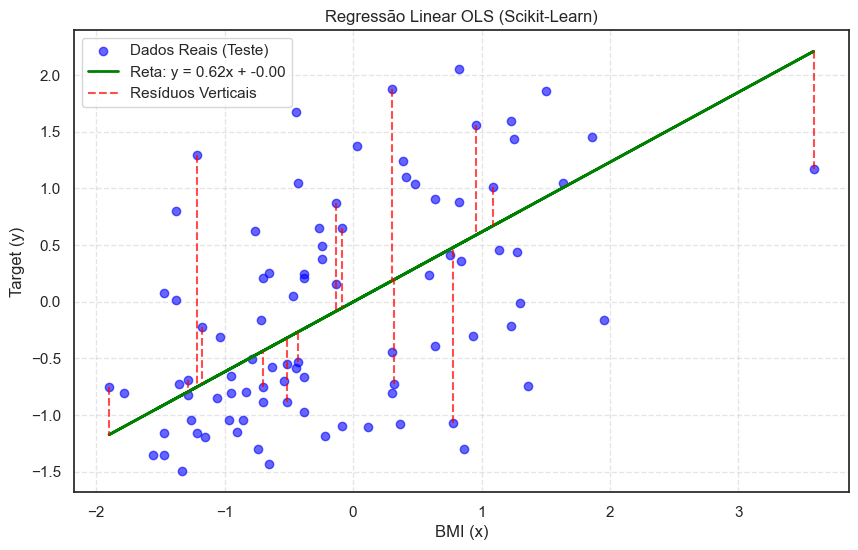

In [192]:
modelo = LinearRegression().fit(X_train_bmi, y_train_bmi)

y_pred_test_ols = modelo.predict(X_test_bmi)
y_pred_all_ols = modelo.predict(X_bmi_scaled)

df_ols = avaliar_modelo_ols(y_test_bmi, y_pred_test_ols, modelo.coef_[0], modelo.intercept_)
display(format_df_left(df_ols, "Parâmetro", casas_decimais=3))

plotar_resultados(
    X_test_bmi,
    y_test_bmi,
    X_bmi_scaled,
    y_pred_all_ols,
    modelo.coef_[0],
    modelo.intercept_,
    "Regressão Linear OLS (Scikit-Learn)",
    "green",
)

### B.1 (Bônus) Regressão Linear Ordinária (OLS) - Derivadas


In [193]:
def derivadas(x, y):
    a = np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sum((x - np.mean(x)) ** 2)
    b = np.mean(y) - a * np.mean(x)
    return a, b


a_deriv, b_deriv = derivadas(X_train_bmi.flatten(), y_train_bmi)

y_pred_test_deriv = a_deriv * X_test_bmi.flatten() + b_deriv

df_deriv = avaliar_modelo_ols(y_test_bmi, y_pred_test_deriv, a_deriv, b_deriv)
display(format_df_left(df_deriv, "Parâmetro", casas_decimais=3))

display(Markdown("### O Resultado é idêntico ao OLS do Scikit-Learn"))

Parâmetro,Valor
Coeficiente (a),0.617
Intercepto (b),-0.002
RMSE (Teste),0.828
R² (Teste),0.233


### O Resultado é idêntico ao OLS do Scikit-Learn

### B.1 (Bônus) Regressão Linear Ordinária (OLS) - Força Bruta

Parâmetro,Valor
Coeficiente (a),0.615
Intercepto (b),-0.002
RMSE (Teste),0.827
R² (Teste),0.234


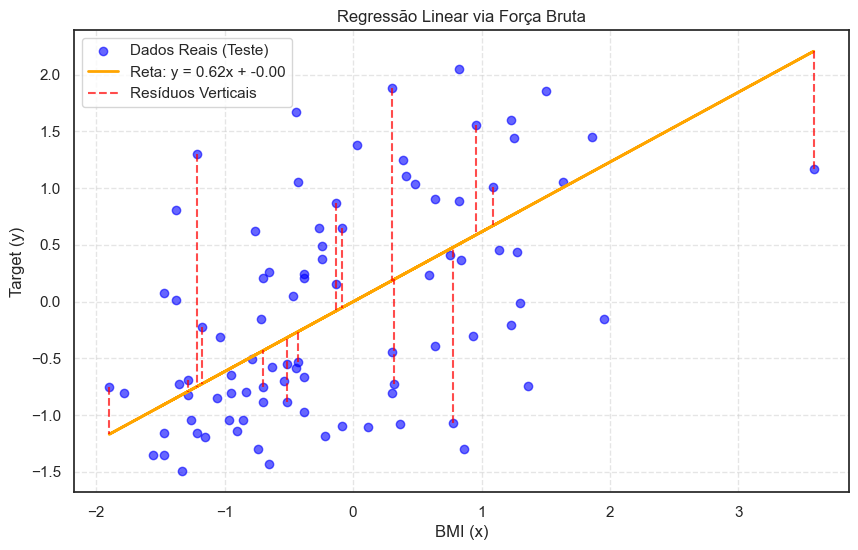

In [194]:
valores_a = np.linspace(0, 2, 300)
valores_b = np.linspace(-1.5, 2, 300)


def calcular_erro(x, y, a, b):
    y_pred = a * x + b
    erro = np.mean((y_pred - y) ** 2)
    return erro


melhor_a, melhor_b, menor_erro = (0, 0, float("inf"))


X_train_flat = X_train_bmi.flatten()
for a in valores_a:
    for b in valores_b:
        erro = calcular_erro(X_train_flat, y_train_bmi, a, b)
        if erro < menor_erro:
            menor_erro, melhor_a, melhor_b = erro, a, b

y_pred_test_fb = melhor_a * X_test_bmi.flatten() + melhor_b
y_pred_all_fb = melhor_a * X_bmi_scaled.flatten() + melhor_b

df_fb = avaliar_modelo_ols(y_test_bmi, y_pred_test_fb, melhor_a, melhor_b)
display(format_df_left(df_fb, "Parâmetro", casas_decimais=3))

plotar_resultados(
    X_test_bmi,
    y_test_bmi,
    X_bmi_scaled,
    y_pred_all_fb,
    melhor_a,
    melhor_b,
    "Regressão Linear via Força Bruta",
    "orange",
)

### B.2 Regressão por Distância Ortogonal (ODR / TLS) - Força Bruta

Parâmetro,Valor
Coeficiente (a),1.032
Intercepto (b),-0.020
RMSE Vertical (Teste),0.997
RMSE Ortogonal (Teste),0.694
R² (Teste),-0.113


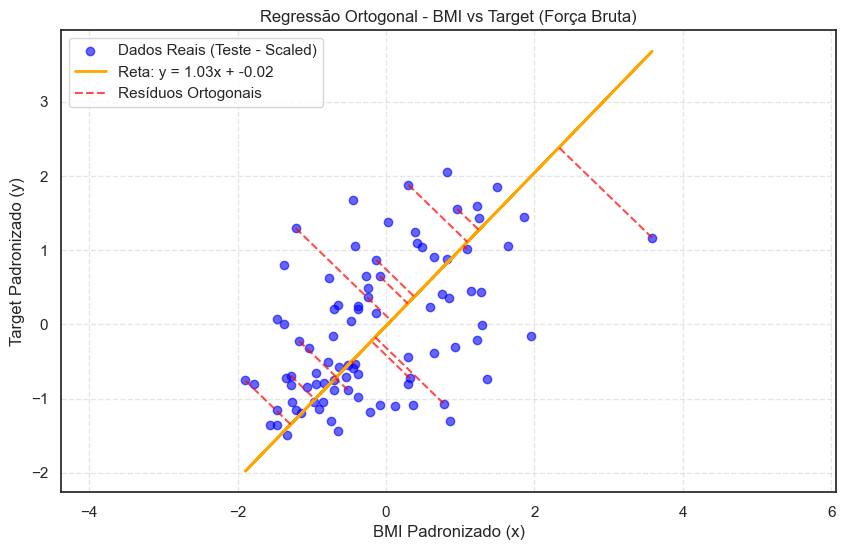

In [ ]:
valores_a = np.linspace(-5, 5, 500)
valores_b = np.linspace(-2, 2, 500)


def calcular_erro_ortogonal(x, y, a, b):
    numerador = np.abs(a * x - y + b)
    denominador = np.sqrt(a**2 + 1)
    distancias_ortogonais = numerador / denominador
    erro = np.mean(distancias_ortogonais**2)
    return erro


melhor_a, melhor_b, menor_erro = (0, 0, float("inf"))

X_train_flat = X_train_bmi.flatten()
y_train_flat = y_train_bmi.flatten()

for a in valores_a:
    for b in valores_b:
        erro = calcular_erro_ortogonal(X_train_flat, y_train_flat, a, b)
        if erro < menor_erro:
            menor_erro, melhor_a, melhor_b = erro, a, b

y_pred_test_fb = melhor_a * X_test_bmi.flatten() + melhor_b
y_pred_all_fb = melhor_a * X_bmi_scaled.flatten() + melhor_b


df_fb = avaliar_modelo_ortogonal(
    X_test_bmi.flatten(), y_test_bmi.flatten(), melhor_a, melhor_b
)
display(format_df_left(df_fb, "Parâmetro", casas_decimais=3))


plotar_resultados_ortogonal(
    X_test=X_test_bmi,
    y_test=y_test_bmi,
    X_all=X_bmi_scaled,
    y_pred_all=y_pred_all_fb,
    a=melhor_a,
    b=melhor_b,
    titulo="Regressão Ortogonal - BMI vs Target (Força Bruta)",
    cor_reta="orange",
)

### Comparação OLS vs ODR


### B.3 Discussão


**1. Em que situações OLS e ODR resultam em retas significativamente diferentes?**

Elas diferem em situações que há baixa correlação entre X e Y, quando ambos têm erros de medição significativos ou quando a diferença de escala entre as variáveis não foram padronizadas

**2. Por que ODR é mais adequado quando tanto X quanto Y têm erro de medição?**

OLS assume que X é medido sem erro, tentando minimizar apenas os erros em Y. Enquanto isso, ODR trata ambas as variáveis como ruidosas, minimizando a distância perpendicular, produzindo estimativas menos enviesadas.

**3. Como a escala/unidades das variáveis afetam a solução ODR (e por que padronizar é útil)?**

ODR minimiza distâncias geométricas. Variáveis em escalas muito diferentes distorcem o ajuste pois a de maior magnitude domina. Padronizar (média 0, desvio 1) equilibra as contribuições.

Exemplo do impacto da escala: Se X varia entre 0-1 e Y entre 0-1000, ODR pode ajustar mais para minimizar erros em Y, ignorando variações em X. Padronizando, ambos contribuem igualmente para o ajuste.

Resultado dos modelos caso não fossem padronizados:

### Regressão Linear OLS sem padronização

Parâmetro,Valor
Coeficiente (a),998.578
Intercepto (b),152.003
RMSE (Teste),63.732
R² (Teste),0.233


### Regressão Ortogonal sem padronização

Parâmetro,Valor
Coeficiente (a),2729.459
Intercepto (b),148.898
RMSE Vertical (Teste),114.914
RMSE Ortogonal (Teste),0.042
R² (Teste),-1.492


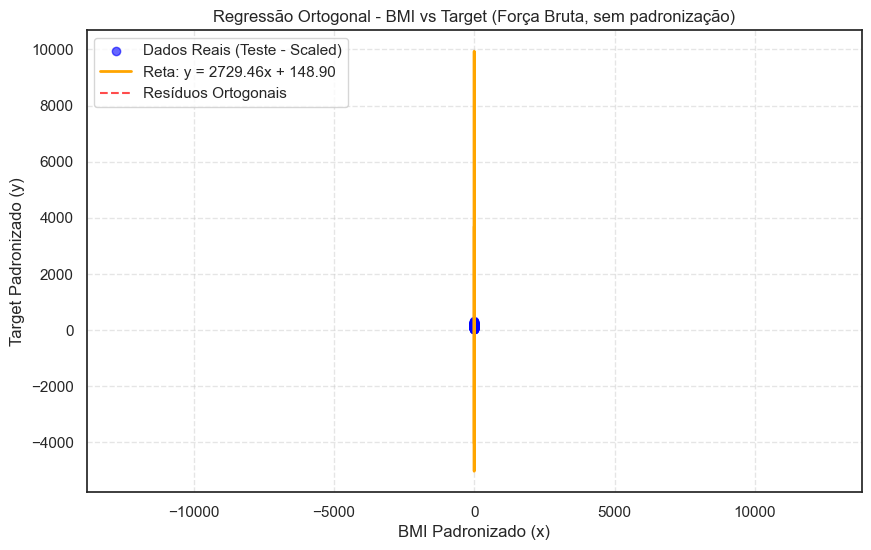

### ODR sem padronização apresenta um ajuste extremamente distorcido devido à diferença de escala das variáveis, resultando em coeficientes muito grandes e um modelo que não captura a relação real entre BMI e Target.

In [210]:
X_train_bmi, X_test_bmi, y_train_bmi, y_test_bmi = train_test_split(
    X_bmi, y, test_size=0.2, random_state=42
)

modelo = LinearRegression().fit(X_train_bmi, y_train_bmi)

y_pred_test_ols = modelo.predict(X_test_bmi)
y_pred_all_ols = modelo.predict(X_bmi)

df_ols = avaliar_modelo_ols(
    y_test_bmi, y_pred_test_ols, modelo.coef_[0], modelo.intercept_
)
display(Markdown("### Regressão Linear OLS sem padronização"))
display(format_df_left(df_ols, "Parâmetro", casas_decimais=3))

valores_a = np.linspace(0, 3000, 500)
valores_b = np.linspace(100, 300, 500)

melhor_a, melhor_b, menor_erro = (0, 0, float("inf"))

X_train_flat = X_train_bmi.flatten()
y_train_flat = y_train_bmi.flatten()

for a in valores_a:
    for b in valores_b:
        erro = calcular_erro_ortogonal(X_train_flat, y_train_flat, a, b)
        if erro < menor_erro:
            menor_erro, melhor_a, melhor_b = erro, a, b

y_pred_test_fb = melhor_a * X_test_bmi.flatten() + melhor_b
y_pred_all_fb = melhor_a * X_bmi_scaled.flatten() + melhor_b

df_fb = avaliar_modelo_ortogonal(
    X_test_bmi.flatten(), y_test_bmi.flatten(), melhor_a, melhor_b
)
display(Markdown("### Regressão Ortogonal sem padronização"))
display(format_df_left(df_fb, "Parâmetro", casas_decimais=3))
plotar_resultados_ortogonal(
    X_test=X_test_bmi,
    y_test=y_test_bmi,
    X_all=X_bmi,
    y_pred_all=y_pred_all_fb,
    a=melhor_a,
    b=melhor_b,
    titulo="Regressão Ortogonal - BMI vs Target (Força Bruta, sem padronização)",
    cor_reta="orange",
)
display(Markdown("### ODR sem padronização apresenta um ajuste extremamente distorcido devido à diferença de escala das variáveis, resultando em coeficientes muito grandes e um modelo que não captura a relação real entre BMI e Target."))

**4. Qual modelo parece generalizar melhor e segundo qual critério?**

O OLS generaliza melhor para previsões. Tendo R² no teste de 0,234, indicando que explica ~23% da variância (baixo, mas positivo). Enquanto isso, ODR apresenta R² = −0,113, o que significa que é pior do que simplesmente usar a média como preditor. Pelo critério de R² no conjunto de teste, o OLS é superior neste caso.
